In [1]:
%matplotlib inline

from astropy.io import fits
import numpy as np

import yaml

import astropy.units as u
from astropy.units import Quantity
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

from astropy.wcs import WCS
from astropy.visualization.wcsaxes import add_beam, add_scalebar

from astropy.coordinates import SkyCoord
# from astropy.nddata.utils import Cutout2D
from radio_beam import Beam

import mosaic_proposal_helper as mph
from mosaic_proposal_helper import plotting
# import plotting
# import core as mph
plt.rcParams.update({"text.usetex": True,
                     "font.family": "serif",
                     'xtick.direction': 'in',
                     'ytick.direction': 'in',
                     'xtick.minor.size': 3,
                     'xtick.major.size': 6,
                     'ytick.minor.size': 3,
                     'ytick.major.size': 6,})

In [2]:
data_dir = "../data/"

In [5]:
def check_point_TdV(pointing, hd, image, threshold):
    my_wcs = WCS(hd)
    ra_out = []
    dec_out = []
    p_out = []
    # for i in range(0, n_points):
    for p in pointing:
        # x, y = my_wcs.world_to_pixel(p.ra, p.dec, 0)
        x, y = my_wcs.world_to_pixel(p)
        if image[int(y), int(x)] > threshold:
            ra_out.append(p.ra)
            dec_out.append(p.dec)
            p_out.append(p)
    return p_out  #,ra_out, dec_out


# @u.quantity_input
# def pb_vla(freq_obs: u.GHz) -> u.arcsec:
#     """
#     Primary beam diameter for VLA at the observed frequency.
#         PB = 42.0 * 60 * (1.0*u.GHz) / freq_obs

#     :param freq_obs: is the observed frequency in GHz.
#     :return: The primary beam FWHM in arcsec
#     """
#     return (42.0 * 60 * u.arcsec * 1.0 * u.GHz / freq_obs).decompose()

def plot_TdV(
    TdV,
    ax:Axes,
    cmap,
    wcs,
    vmin: float | None = None,
    vmax: float | None = None,
    distance: Quantity[u.pc] = 140 * u.pc,
    label_col: str = "white",
) -> None:
    # plot continuum in color
    im = ax.imshow(
        TdV.data,
        origin="lower",
        interpolation="None",
        cmap=cmap,
        alpha=1.0,
        transform=ax.get_transform(wcs),
        vmin=vmin,
        vmax=vmax,
    )
    length = (0.1 * u.pc / distance).to(u.deg, u.dimensionless_angles())
    add_scalebar(ax, length, label=r"0.1 pc", color=label_col, corner="bottom right")
    # add beam
    add_beam(
        ax,
        header=TdV.header,
        frame=False,
        pad=0.4,
        facecolor=label_col,
        corner="bottom left",
        edgecolor='black',
    )
    RA = ax.coords[0]
    DEC = ax.coords[1]
    RA.set_axislabel(r"$\alpha$ (J2000)", minpad=0.7)
    DEC.set_major_formatter("dd:mm")
    RA.set_major_formatter("hh:mm:ss")
    DEC.set_axislabel(r"$\delta$ (J2000)", minpad=0.8)
    DEC.set_ticklabel(rotation=90.0, color="black", exclude_overlapping=True)
    RA.set_ticklabel(color="black", exclude_overlapping=True)
    DEC.set_ticks(spacing=600 * u.arcsec, color="black")
    RA.set_ticks(spacing=60.0 * 15 * u.arcsec, color="black")
    RA.display_minor_ticks(True)
    DEC.display_minor_ticks(True)
    DEC.set_minor_frequency(5)
    RA.set_minor_frequency(5)
    return

def wrap_TdV_pointings(file_in: str, source_catalogue: str, distance: Quantity[u.pc]=300 * u.pc, label_col: str="black", threshold: float=1.0, vmin: float | None = None, vmax: float | None = None,) -> tuple[Axes, list]:
    TdV_11 = fits.open(data_dir + file_in)[0]
    wcs_TdV_11 = WCS(TdV_11.header)

    fig2 = plt.figure(figsize=(7, 7))
    ax2 = fig2.add_subplot(111, projection=wcs_TdV_11)
    plot_TdV(
        TdV_11,
        ax2,
        color_map,
        wcs_TdV_11,
        vmin=vmin,
        vmax=vmax,
        distance=distance,
        label_col=label_col,
    )
    pointings_all = []
    for source_i in catalogue.keys():
        if source_i.startswith(source_catalogue):
            center = SkyCoord(catalogue[source_i]["RA0"], catalogue[source_i]["Dec0"], unit=(u.hourangle, u.deg))
            width = u.Quantity(catalogue[source_i]["width"])
            height = u.Quantity(catalogue[source_i]["height"])
            pa = u.Quantity(catalogue[source_i]["PA"])
            pointings = mph.compute_pointings(
                center.ra,
                center.dec,
                width=width,
                height=height,
                pb=PB,
                pa=pa,
            )

            pointings_cut = check_point_TdV(pointings, TdV_11.header, TdV_11.data, threshold)
            for p in pointings_cut:
                pointings_all.append(p)
                plotting.plot_circle_wcs(ax2, (p.ra, p.dec), PB/2, edgecolor="white", lw=0.5, alpha=1)
    return ax2, pointings_all

In [6]:
catalogue = yaml.safe_load(open("../data/catalogue_boxes.yml", "r"))
PB = plotting.pb_interferometer(22.3 * u.GHz, telescope='vla')

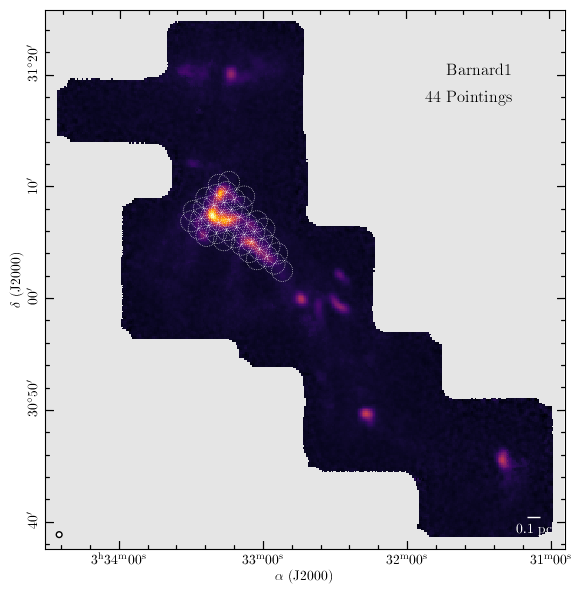

In [8]:
plt.ion()
plt.close("all")
# Example usage
distance = 300 * u.pc
source_catalogue = "Barnard1"
source = "Barnard1"
B1_TdV = 'B1_NH3_11_all_rebase3_mom0_QA_trim.fits'

#  prepare colors
label_col = "black"
label_col = "white"
cmap_mom0_default = "inferno"
color_nan = "0.9"
color_map = plt.get_cmap(cmap_mom0_default).copy()
color_map.set_bad(color=color_nan)
vmin = -0.2
vmax = 6.0

ax2, pointings_cut = wrap_TdV_pointings(B1_TdV, source_catalogue, distance, label_col)


ax2.text(0.9, 0.9, "Barnard1", transform=ax2.transAxes, ha="right", va="top", color='black', fontsize=12)
ax2.text(0.9, 0.85, f"{len(pointings_cut)} Pointings", transform=ax2.transAxes, ha="right", va="top", color='black', fontsize=12)
plt.savefig(f'{source}_pointings.pdf', bbox_inches='tight')

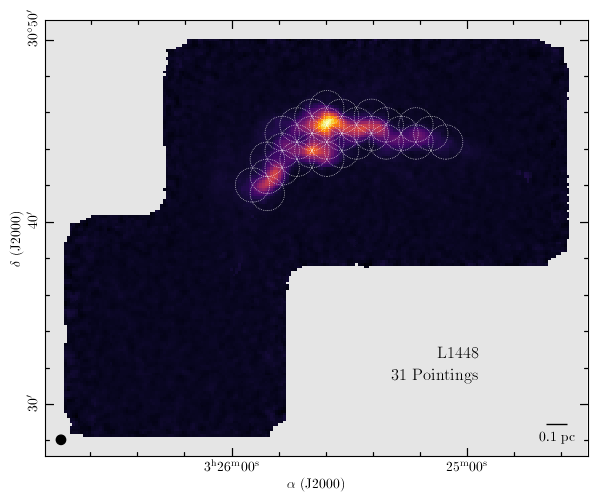

In [9]:
plt.ion()
plt.close("all")

# Prepare source
distance = 300 * u.pc
source_catalogue = "L1448_"
source = "L1448"
L1448_TdV = 'L1448_NH3_11_all_rebase3_mom0_QA_trim.fits'

#  prepare colors
label_col = "black"
cmap_mom0_default = "inferno"
color_nan = "0.9"
color_map = plt.get_cmap(cmap_mom0_default).copy()
color_map.set_bad(color=color_nan)
vmin = -0.2
vmax = 6.0

ax2, pointings_cut = wrap_TdV_pointings(L1448_TdV, source_catalogue, distance, label_col, threshold=1.0)
ax2.text(0.8, 0.25, f'{source}', transform=ax2.transAxes, ha="right", va="top", color='black', fontsize=12)
ax2.text(0.8, 0.2, f"{len(pointings_cut)} Pointings", transform=ax2.transAxes, ha="right", va="top", color='black', fontsize=12)

plt.savefig(f'{source}_pointings.pdf', bbox_inches='tight')

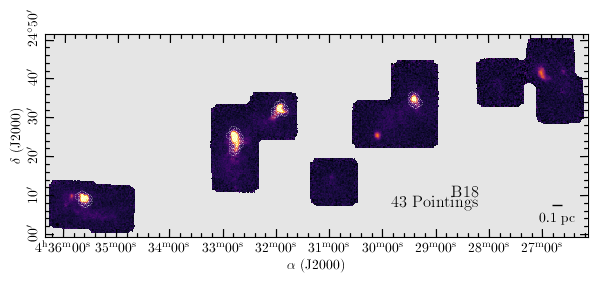

In [10]:
plt.ion()
plt.close("all")

# Prepare source
distance = 145 * u.pc
source_catalogue = "B18-"
source = "B18"
B18_TdV = 'B18_NH3_11_all_rebase3_mom0_QA_trim.fits'

#  prepare colors
label_col = "black"
cmap_mom0_default = "inferno"
color_nan = "0.9"
color_map = plt.get_cmap(cmap_mom0_default).copy()
color_map.set_bad(color=color_nan)
vmin = -0.5
vmax = 5.0

ax2, pointings_cut = wrap_TdV_pointings(B18_TdV, source_catalogue, distance, label_col, threshold=1.0, vmin=vmin, vmax=vmax)
ax2.text(0.8, 0.25, f'{source}', transform=ax2.transAxes, ha="right", va="top", color='black', fontsize=12)
ax2.text(0.8, 0.2, f"{len(pointings_cut)} Pointings", transform=ax2.transAxes, ha="right", va="top", color='black', fontsize=12)

plt.savefig(f'{source}_pointings.pdf', bbox_inches='tight')

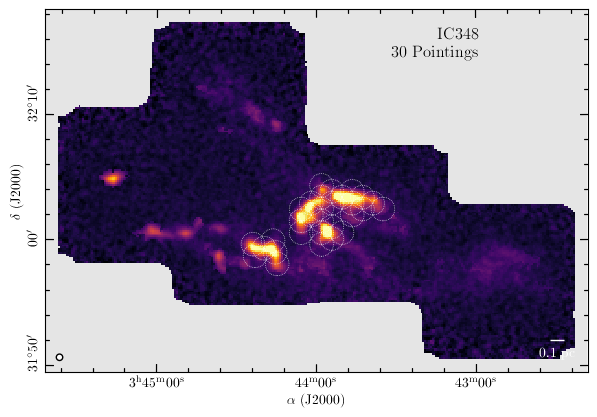

In [11]:
plt.ion()
plt.close("all")

# Prepare source
distance = 300 * u.pc
source_catalogue = "IC348-"
source = "IC348"
IC348_TdV = 'IC348_NH3_11_all_rebase3_mom0_QA_trim.fits'

#  prepare colors
label_col = "white"
cmap_mom0_default = "inferno"
color_nan = "0.9"
color_map = plt.get_cmap(cmap_mom0_default).copy()
color_map.set_bad(color=color_nan)
vmin = -0.5
vmax = 5.0

ax2, pointings_cut = wrap_TdV_pointings(IC348_TdV, source_catalogue, distance, label_col, threshold=1.0, vmin=vmin, vmax=vmax)
ax2.text(0.8, 0.95, f'{source}', transform=ax2.transAxes, ha="right", va="top", color='black', fontsize=12)
ax2.text(0.8, 0.9, f"{len(pointings_cut)} Pointings", transform=ax2.transAxes, ha="right", va="top", color='black', fontsize=12)

plt.savefig(f'{source}_pointings.pdf', bbox_inches='tight')